In [2]:
import torch

if torch.cuda.is_available():
    device="cuda"
else:
    device = "cpu"
print(f"Using device {device}")

Using device cpu


In [3]:
BASE_CONFIG = {
    "vocab_size": 32000,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": True,
    "emb_dim": 768, 
    "n_layers": 12, 
    "n_heads": 12      
}


In [4]:
from tokenizers import Tokenizer
from gpt2 import *
# Load the trained custom tokenizer
tokenizer = Tokenizer.from_file("guj_bpe_tokenizer.json")

In [5]:
import json

with open("data.json", "r", encoding="utf-8") as f:
    data = json.load(f)

In [6]:

def format_input(entry):
    instruction_text = (
        f"<|user|>\n{entry['instruction']}"
    )

    input_text = f"\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [7]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=512):
        self.data = []
        self.encoded_texts = []
        self.instruction_lengths = []

        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"<|assistant|>\n{entry['output']}"
            full_text = instruction_plus_input + response_text

            ids = tokenizer.encode(full_text).ids

            if len(ids) > max_length:
                continue

            self.encoded_texts.append(ids)
            self.instruction_lengths.append(len(tokenizer.encode(instruction_plus_input).ids))
            self.data.append(entry)  # Optionally keep for reference
        
    def __getitem__(self, index):
        return self.instruction_lengths[index], self.encoded_texts[index]

    def __len__(self):
        return len(self.encoded_texts)


In [8]:
def custom_collate_fn(
    batch,
    pad_token_id=0,
    ignore_index=-100,
    allowed_max_length=512,
    device=device
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for instruction_length, item in batch)   # New: batch is now a tuple
    if batch_max_length > 512:
        print(f"\n🚨 Batch exceeds 1024 tokens (length = {batch_max_length})")
    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for instruction_length, item in batch:  # New: batch is now a tuple
        new_item = item.copy() # List of Tokens for each input sample in a batch
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        ##########################################################################################
        # New: Mask all input and instruction tokens in the targets
        targets[:instruction_length-1] = -100
        ##########################################################################################
        
        # Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
        
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [9]:
from torch.utils.data import DataLoader, random_split

# Assume you have `data` (list of dicts or dataframe), and a tokenizer
full_dataset = InstructionDataset(data, tokenizer)

# train_dataset = InstructionDataset(data[0:3], tokenizer)


# Define split ratio (e.g., 90% train, 10% test)
train_size = int(0.9 * len(full_dataset))
test_size = len(full_dataset) - train_size

# Split dataset
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    collate_fn=custom_collate_fn,
    num_workers=0,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    collate_fn=custom_collate_fn,
    num_workers=0,
    shuffle=False,
)


In [10]:
import math
class LoRALayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        self.A = torch.nn.Parameter(torch.empty(in_dim, rank))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        self.B = torch.nn.Parameter(torch.zeros(rank, out_dim))
        self.alpha = alpha
    def forward(self, x):
        x = self.alpha * (x @ self.A @ self.B)
        return x

In [11]:
class LinearWithLoRA(torch.nn.Module):
 def __init__(self, linear, rank, alpha):
    super().__init__()
    self.linear = linear
    self.lora = LoRALayer(
    linear.in_features, linear.out_features, rank, alpha
    )
 def forward(self, x):
    return self.linear(x) + self.lora(x)

In [12]:
model = GPTModel(BASE_CONFIG)
# replace_linear_with_lora(model, rank=16, alpha=16)  # your LoRA insertion function

In [13]:
# def replace_linear_with_lora(model, rank, alpha):
#  for name, module in model.named_children():
#     if isinstance(module, torch.nn.Linear):
#         setattr(model, name, LinearWithLoRA(module, rank, alpha))
#     else:
#         replace_linear_with_lora(module, rank, alpha)

In [14]:
# # 1. Count all trainable params (before freezing)
# total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f"Total trainable parameters before: {total_params:,}")

# # 2. Inject LoRA
# replace_linear_with_lora(model, rank=16, alpha=16)

# # 3. Freeze base model only
# for name, param in model.named_parameters():
#     if "lora" not in name:
#         param.requires_grad = False

# # 4. Count LoRA trainable params
# total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f"Total trainable LoRA parameters: {total_params:,}")


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("best_model.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)


GPTModel(
  (tok_emb): Embedding(32000, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [ ]:
import torch
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
import os
import random

# === Reproducibility ===
seed = 42
torch.manual_seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)

# === Setup ===
weight_decay = 0.01  # Regularization to prevent overfitting
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=weight_decay)
model.to(device)

epochs = 15
warmup_steps = 1000
max_grad_norm = 1.0
patience = 3
best_loss = float('inf')
best_epoch = 0
counter = 0

total_steps = len(train_loader) * epochs

# === Scheduler ===
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# === Save Paths ===
save_dir = 'saved_models'
os.makedirs(save_dir, exist_ok=True)
log_file = os.path.join(save_dir, "loss_log.txt")

# === Clear Log ===
with open(log_file, "w") as f:
    f.write("Epoch\tTrain Loss\tTest Loss\n")

# === Training Loop ===
for epoch in range(epochs):
    model.train()
    train_loss = 0

    for step, (x, y) in enumerate(train_loader):
        optimizer.zero_grad()

        # === Mixed Precision ===
        with torch.autocast(device_type=str(device), dtype=torch.bfloat16):
            loss = calc_loss_batch(x, y, model, device)

        loss.backward()

        # === Gradient Clipping ===
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # === Evaluation ===
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for x, y in test_loader:
            with torch.autocast(device_type=str(device), dtype=torch.bfloat16):
                loss = calc_loss_batch(x, y, model, device)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}")
    log_line = f"{epoch+1}\t{avg_train_loss:.4f}\t{avg_test_loss:.4f}"
    
    with open(log_file, "a") as f:
        f.write(log_line + "\n")

    # === Early Stopping ===
    if avg_test_loss < best_loss:
        best_loss = avg_test_loss
        best_epoch = epoch + 1
        counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch + 1,
            'test_loss': avg_test_loss,
        }, os.path.join(save_dir, 'best_model.pth'))
        print("Model saved.")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs without improvement.")
            print(f"Best model was at epoch {best_epoch} with test loss {best_loss:.4f}")
            break


In [30]:
entry =   {
    "instruction": "એક વાક્ય બનાવો જે આશ્ચર્ય વ્યક્ત કરે છે.?",
    "input": "",
    "output": "હું તેનો વિશ્વાસ કરી શકતો નથી!"
  }
# print(entry)
input_text = format_input(entry)

token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer).to(device),
    max_new_tokens=512,
    context_size=BASE_CONFIG["context_length"],
    eos_id=0
)

generated_text = token_ids_to_text(token_ids, tokenizer)
# generated_text = tokenizer.decode(token_ids,skip_special_tokens=False)

print(input_text[8:])
# print(f"\nCorrect response:\n>> {entry['output']}")
print(f"\n{generated_text}")
print("-------------------------------------")


એક વાક્ય બનાવો જે આશ્ચર્ય વ્યક્ત કરે છે.?

<|assistant|> હું તેનો વિશ્વાસ કરી શકતો નથી !
-------------------------------------


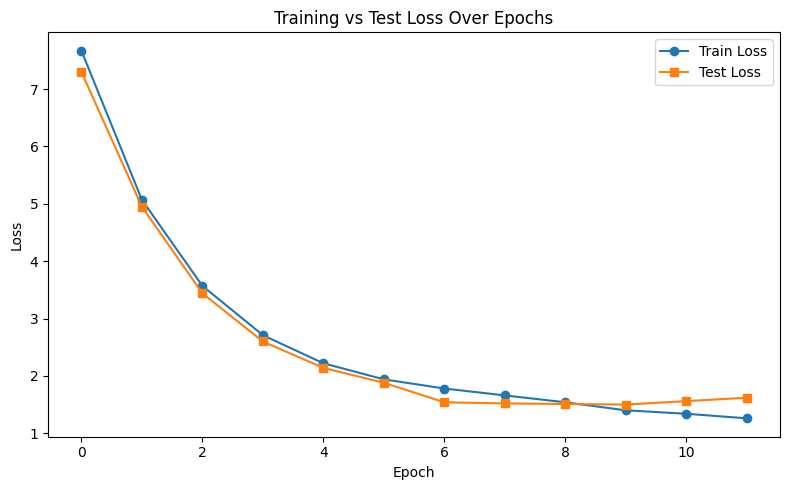

In [35]:
import matplotlib.pyplot as plt

# Epochs
epochs = [0, 1, 2, 3,4,5,6,7,8,9,10,11]

# Training and Test Losses
train_loss = [7.67, 5.07, 3.57, 2.71, 2.22, 1.94, 1.78, 1.66, 1.54, 1.4, 1.34,1.26]
test_loss = [7.3, 4.95, 3.44, 2.6, 2.14, 1.88, 1.54, 1.52, 1.51, 1.5,1.56,1.62]


# Plotting
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, test_loss, marker='s', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Test Loss Over Epochs')
plt.legend()
plt.tight_layout()
plt.show()
